# Example A: Another Synthetic Example

In [1]:
# !pip install git+https://github.com/sichinaga/PyDMD@sparse-mode-bopdmd-FINAL

import numpy as np
import matplotlib.pyplot as plt

from pydmd import BOPDMD, SparseBOPDMD
from pydmd.sbopdmd_utils import *

def error(actual, truth):
    """
    Compute relative error.
    """
    return np.linalg.norm(actual - truth) / np.linalg.norm(truth)

import warnings
warnings.filterwarnings("ignore")

## Part 1: Build the data set

In [2]:
# SET ALL DATA PARAMETERS:
nx = 50  # number of pixels along the horizontal
ny = nx  # number of pixels along the vertical
n = nx * ny  # number of features
nt = 1001  # number of time points
dt = 0.01  # time-step size

# Define the spatial and temporal grid.
x = np.arange(nx)
y = np.arange(ny)
t = np.arange(nt) * dt
Xgrid, Ygrid = np.meshgrid(x, y)

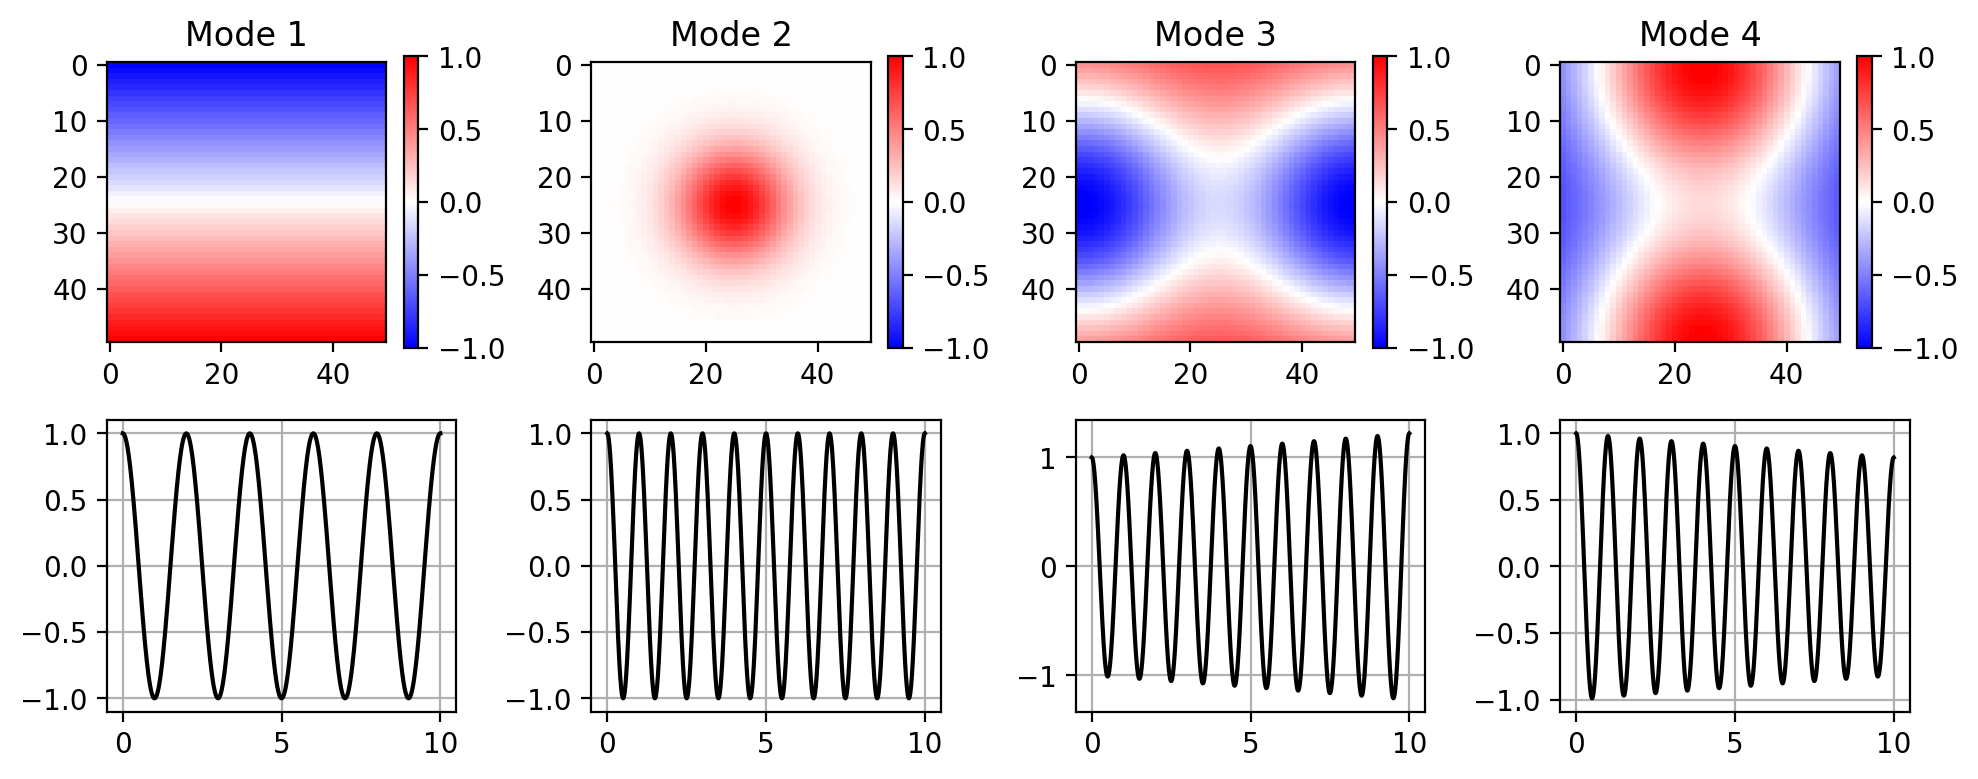

In [3]:
## EIGENVALUES:
# Define the true frequencies.
true_f = np.array([0.5, 1.0, 1.0, 1.0])

# Define the true DMD eigenvalues.
true_eigs = 1j * 2 * np.pi * true_f

# Incorporate growth / decay:
true_eigs[-2] += 0.02
true_eigs[-1] -= 0.02

## MODES:
# Define mode 1 (oscillating global gradient mode).
u1 = np.tile(np.linspace(-1, 1, nx), (ny, 1)).T

# Define mode 2 (oscillating Gaussian mode).
u2 = np.exp(-(0.5 / nx) * ((Xgrid - 0.5 * nx) ** 2 + (Ygrid - 0.5 * ny) ** 2))

# Define mode 3 (growing global mode).
u3 = np.ones((nx, ny))
u3 -= 2 * np.exp(-(0.1 / nx) * (Xgrid ** 2 + (Ygrid - 0.5 * ny) ** 2))
u3 -= 2 * np.exp(-(0.1 / nx) * ((Xgrid - nx) ** 2 + (Ygrid - 0.5 * ny) ** 2))

# Define mode 4 (decaying global mode).
u4 = -np.ones((nx, ny))
u4 += 2 * np.exp(-(0.1 / nx) * (Ygrid ** 2 + (Xgrid - 0.5 * nx) ** 2))
u4 += 2 * np.exp(-(0.1 / nx) * ((Ygrid - ny) ** 2 + (Xgrid - 0.5 * nx) ** 2))

# Store the true modes.
true_modes = [u1, u2, u3, u4]
true_modes = np.array(true_modes).reshape(4, -1)

plt.figure(figsize=(10, 4), dpi=200)
for i, (eig, mode) in enumerate(zip(true_eigs, true_modes)):
    plt.subplot(2, len(true_eigs), i + 1)
    plt.title(f"Mode {i + 1}")
    plt.imshow(mode.reshape(ny, nx), cmap="bwr", vmin=-1, vmax=1)
    plt.colorbar()
    plt.subplot(2, len(true_eigs), i + len(true_eigs) + 1)
    plt.plot(t, np.exp(eig * t).real, c="k")
    plt.grid()
plt.tight_layout()
plt.show()

In [4]:
# Define true amplitudes.
true_amps = [1, 1, 1, 1]

# Build (clean) data matrix.
X_clean = np.zeros((n, nt), dtype="complex")
for j, (eig, mode, b) in enumerate(zip(true_eigs, true_modes, true_amps)):
    X_clean += b * np.outer(mode, np.exp(eig * t))

# Add measurement noise.
rng1 = np.random.default_rng(seed=1234)
rng2 = np.random.default_rng(seed=5678)

sigma = 0.004 # noise magnitude
real_noise = sigma * rng1.standard_normal((n, nt))
imag_noise = sigma * 1j * rng2.standard_normal((n, nt))

X = X_clean + real_noise + imag_noise

print("Data successfully generated!")
print(f"Data dimensions in (space, time): {X.shape}")

Data successfully generated!
Data dimensions in (space, time): (2500, 1001)


## Part 2: Apply Optimized DMD

In [5]:
def plot_dmd_results(dmd_modes, dmd_eigs):
    """
    Helper function for comparing computed modes and eigs to the truth.
    """
    fig = plt.figure(figsize=(10, 6), dpi=200)
    mode_axes = [fig.add_subplot(3, 4, i + 1) for i in range(8)]
    eig_ax = fig.add_subplot(3, 1, 3)

    for i, (ax, mode) in enumerate(zip(mode_axes, np.vstack([true_modes, dmd_modes]))):
        vmax = np.abs(mode).max()
        im = ax.imshow(
            mode.reshape(ny, nx),
            cmap="bwr",
            vmin=-vmax,
            vmax=vmax,
        )
        fig.colorbar(im, ax=ax)
        if i == 0:
            ax.set_ylabel("True Modes")
        elif i == 4:
            ax.set_ylabel("DMD Modes")

    eig_ax.plot(true_eigs.real, true_eigs.imag, "o", c="k", mfc="none", label="True Eigenvalues")
    eig_ax.plot(dmd_eigs.real, dmd_eigs.imag, "+", c="r", label="DMD Eigenvalues")
    eig_ax.set_xlabel("Re($\\omega_j$)")
    eig_ax.set_ylabel("Im($\\omega_j$)")
    eig_ax.legend(loc="lower left")
    eig_ax.grid()

    plt.tight_layout()
    plt.show()

Using clean data, DMD is able to identify all modes.

Model Error = 7.676163691337532e-05%


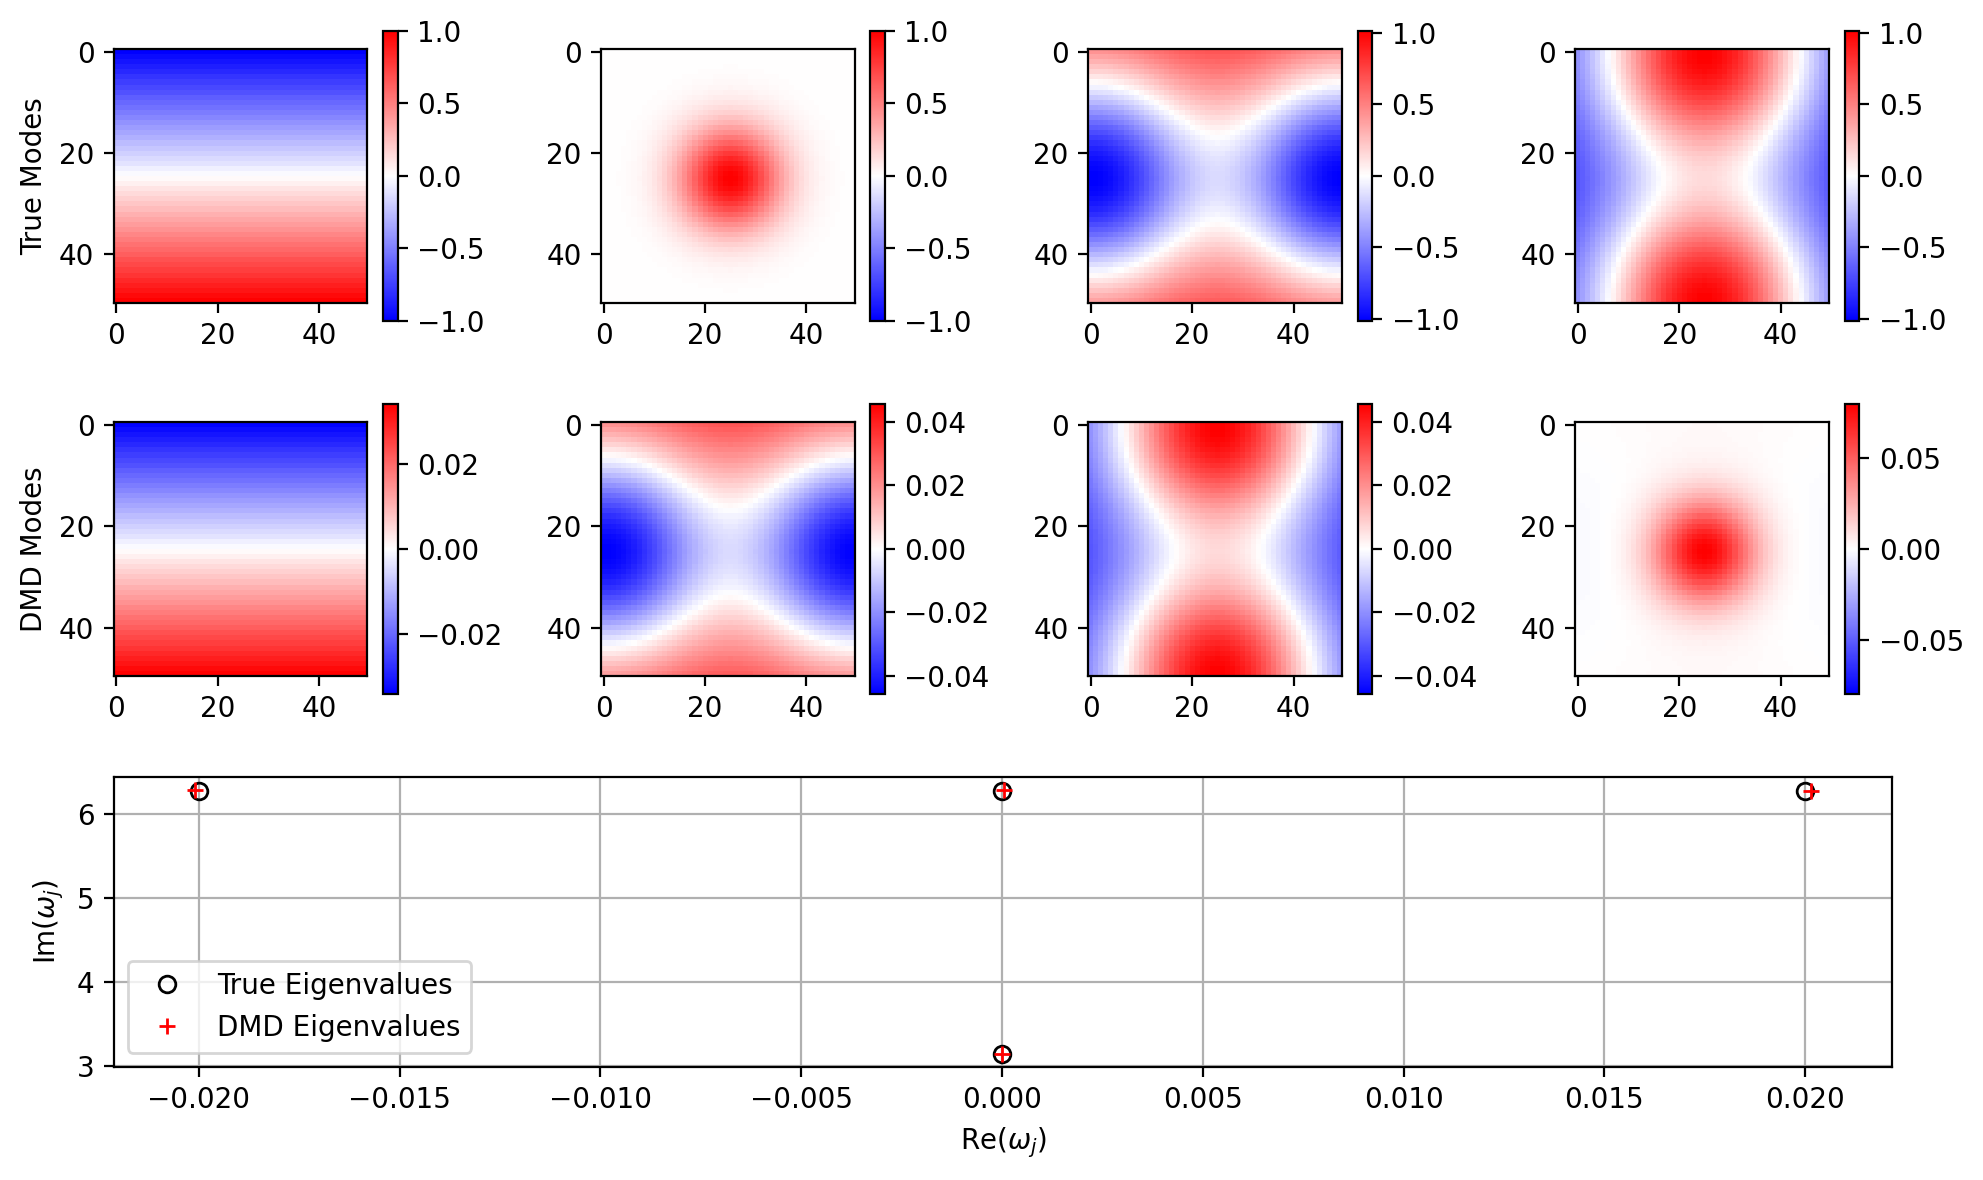

In [6]:
optdmd = BOPDMD(svd_rank=4).fit(X_clean, t)
print(f"Model Error = {100 * error(optdmd.reconstructed_data, X_clean)}%")
plot_dmd_results(optdmd.modes.real.T, optdmd.eigs)

When enough noise is added to the data, DMD loses the Gaussian spatial signature.

Model Error = 0.0345346429178347%


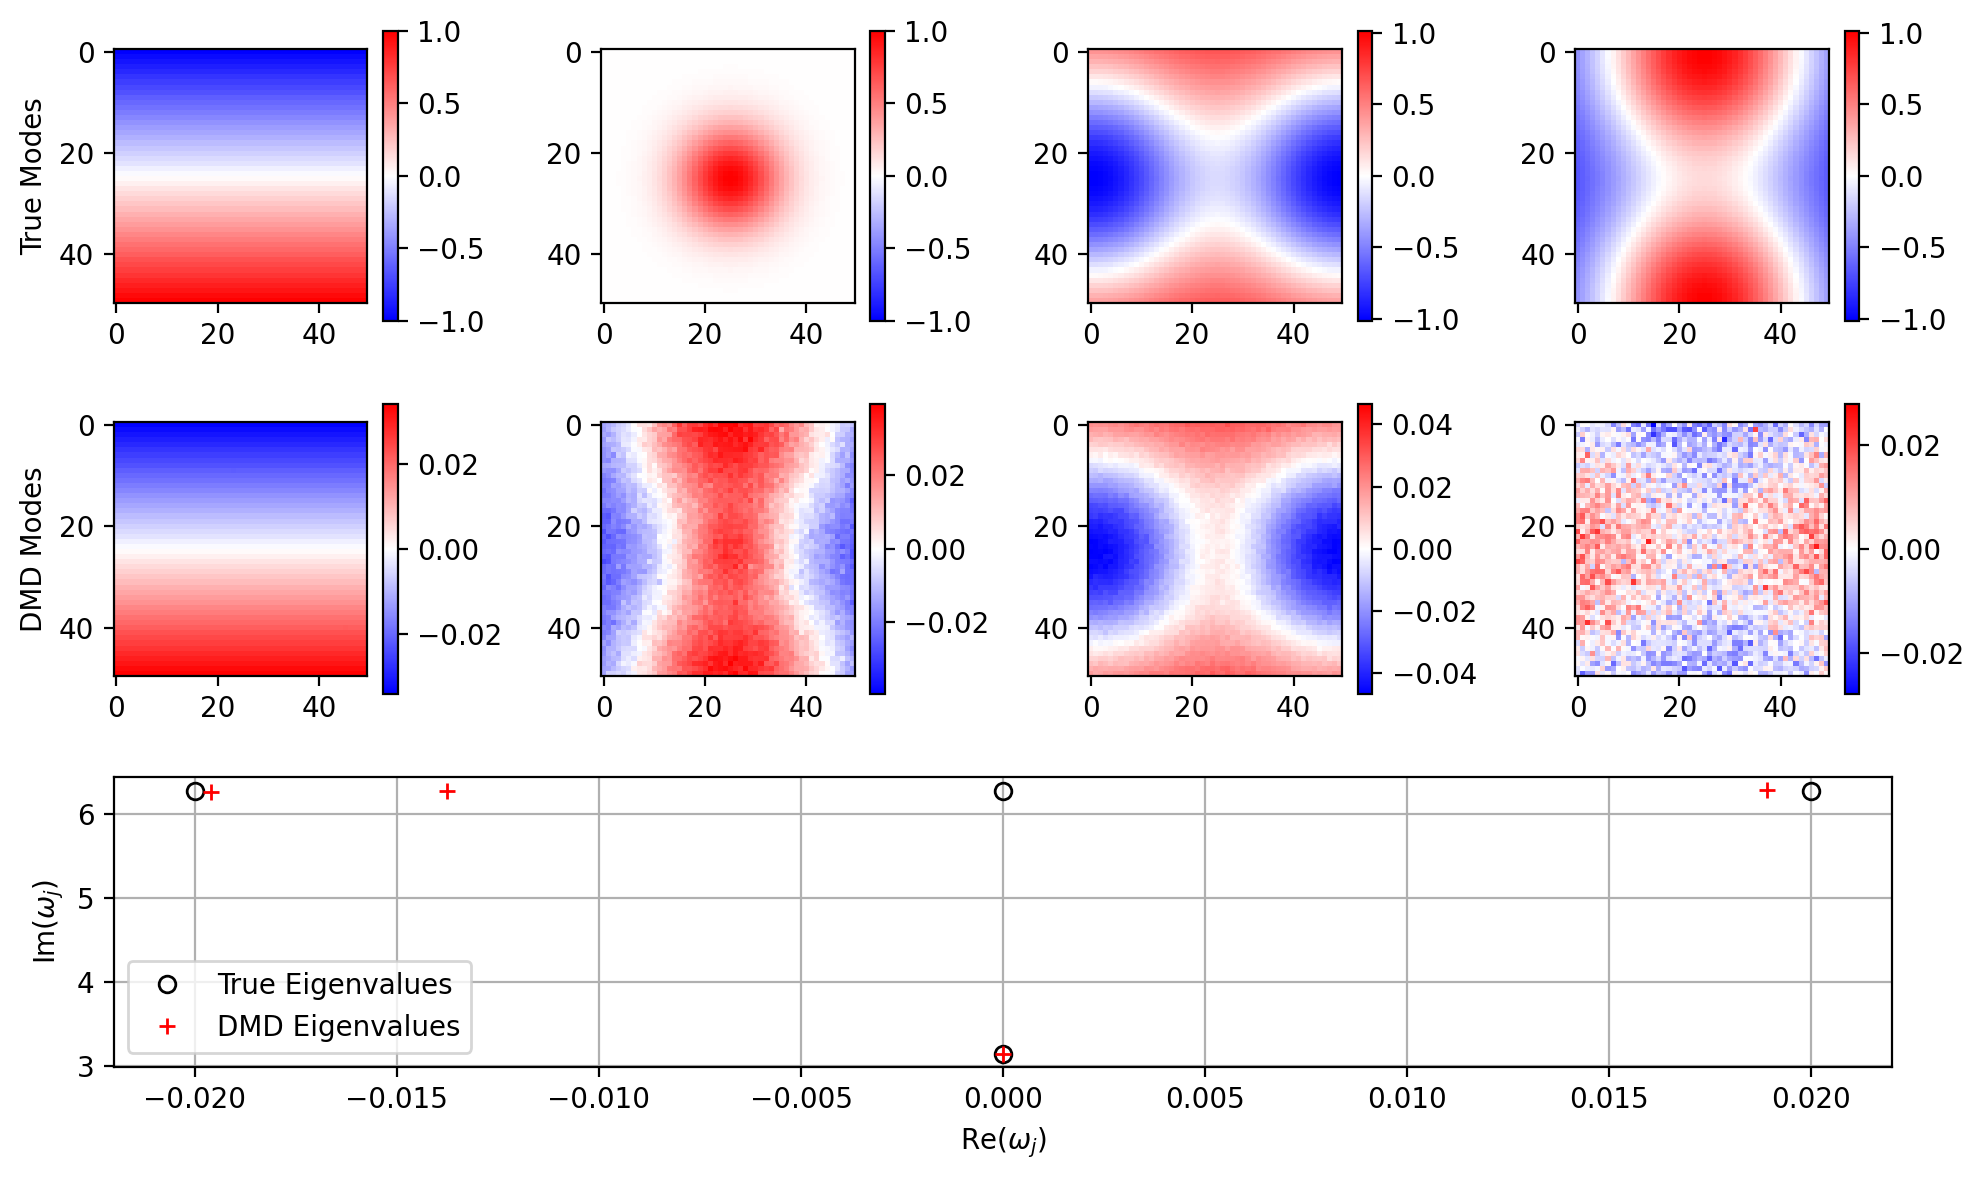

In [7]:
optdmd = BOPDMD(svd_rank=4).fit(X, t)
print(f"Model Error = {100 * error(optdmd.reconstructed_data, X_clean)}%")
plot_dmd_results(optdmd.modes.real.T, optdmd.eigs)

## Part 3: Apply Sparse-mode DMD

Although both optimized and sparse-mode DMD mix the spatiotemporal modes that share a frequency,

sparse-mode DMD is able to detect the presence of what appears to be a spatially local Gaussian mode

(while also achieving comparable reconstruction error to optimized DMD).

Results for lambda = 2e-06:
Model Error = 0.034177159402946806%


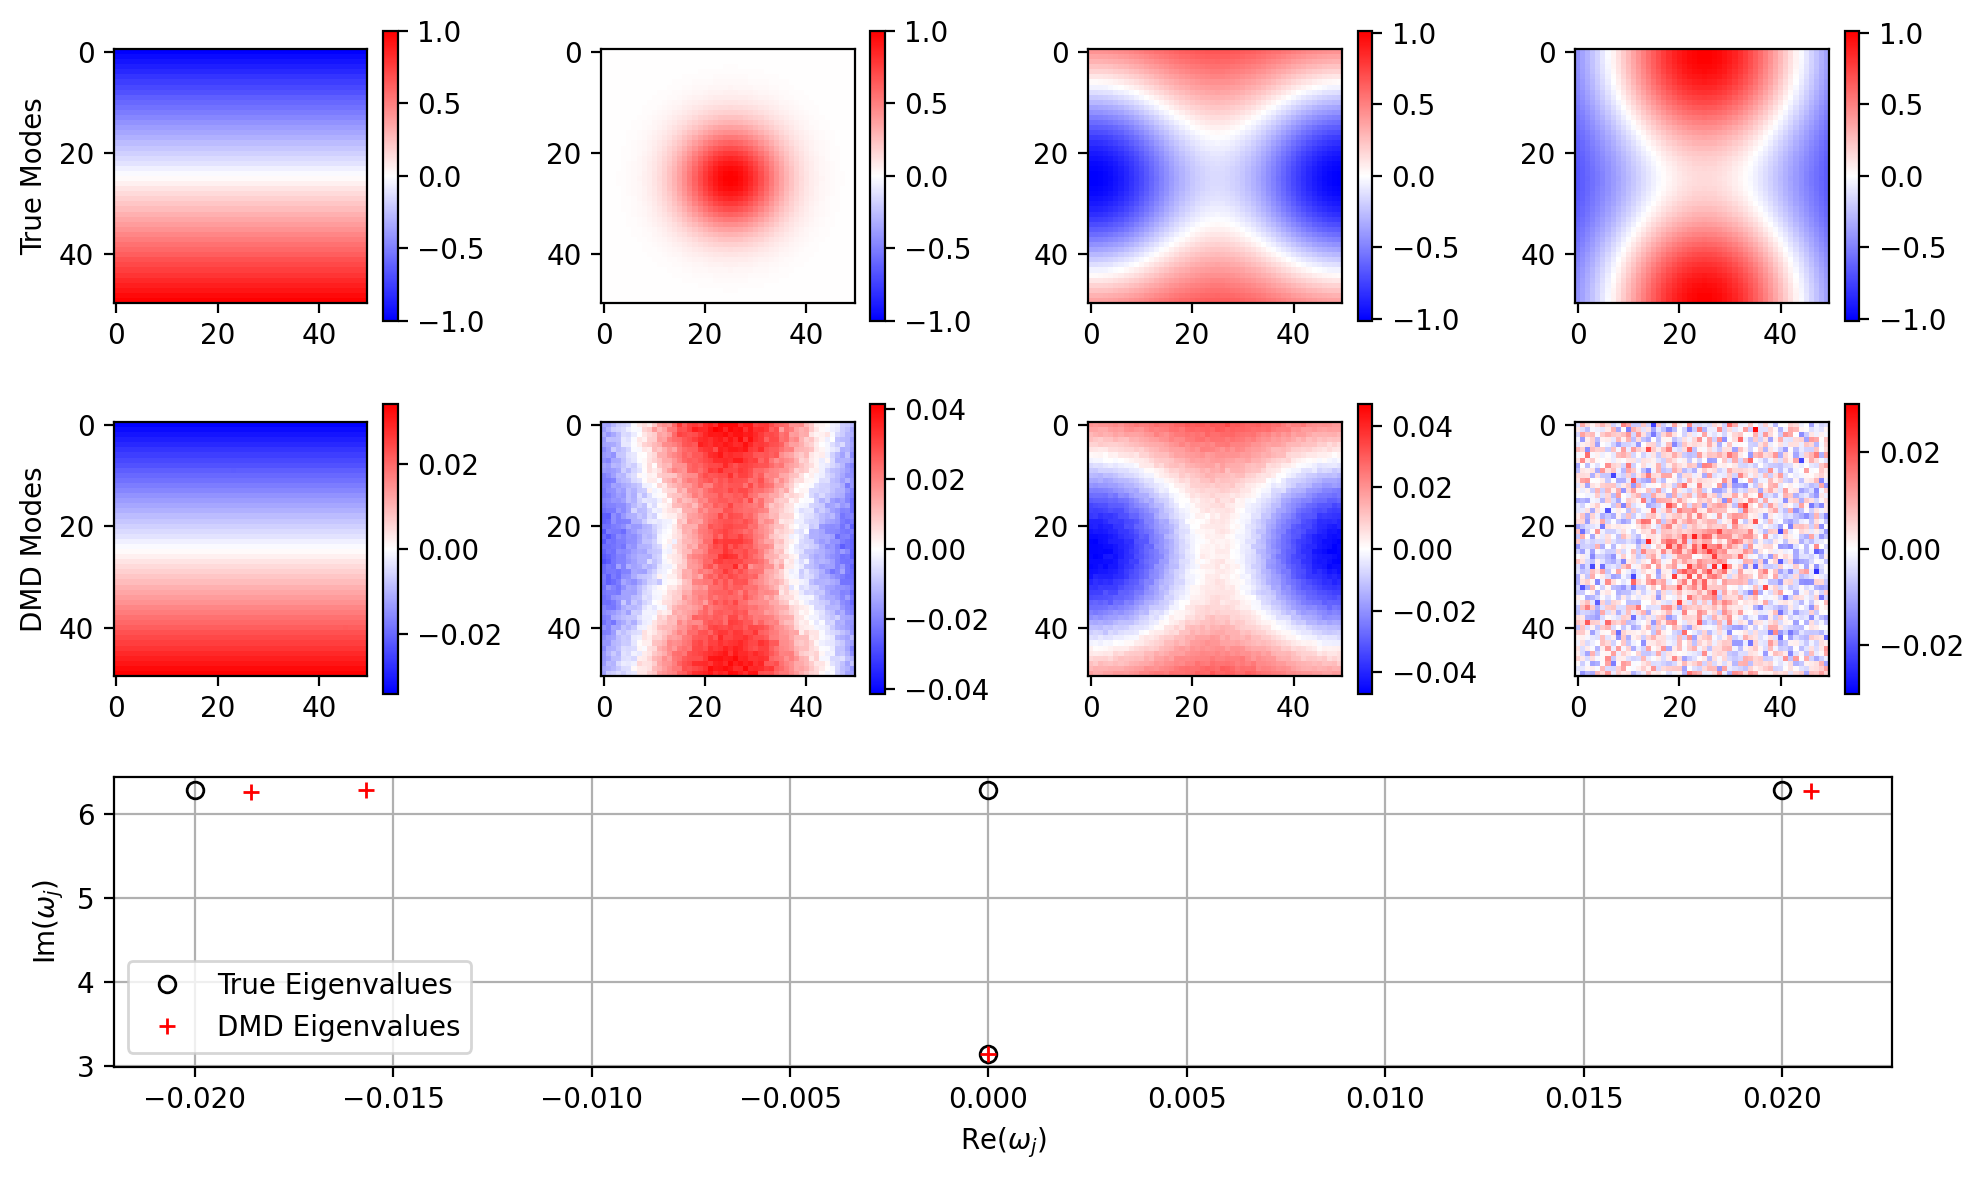

Results for lambda = 4e-06:
Model Error = 0.03418124839159014%


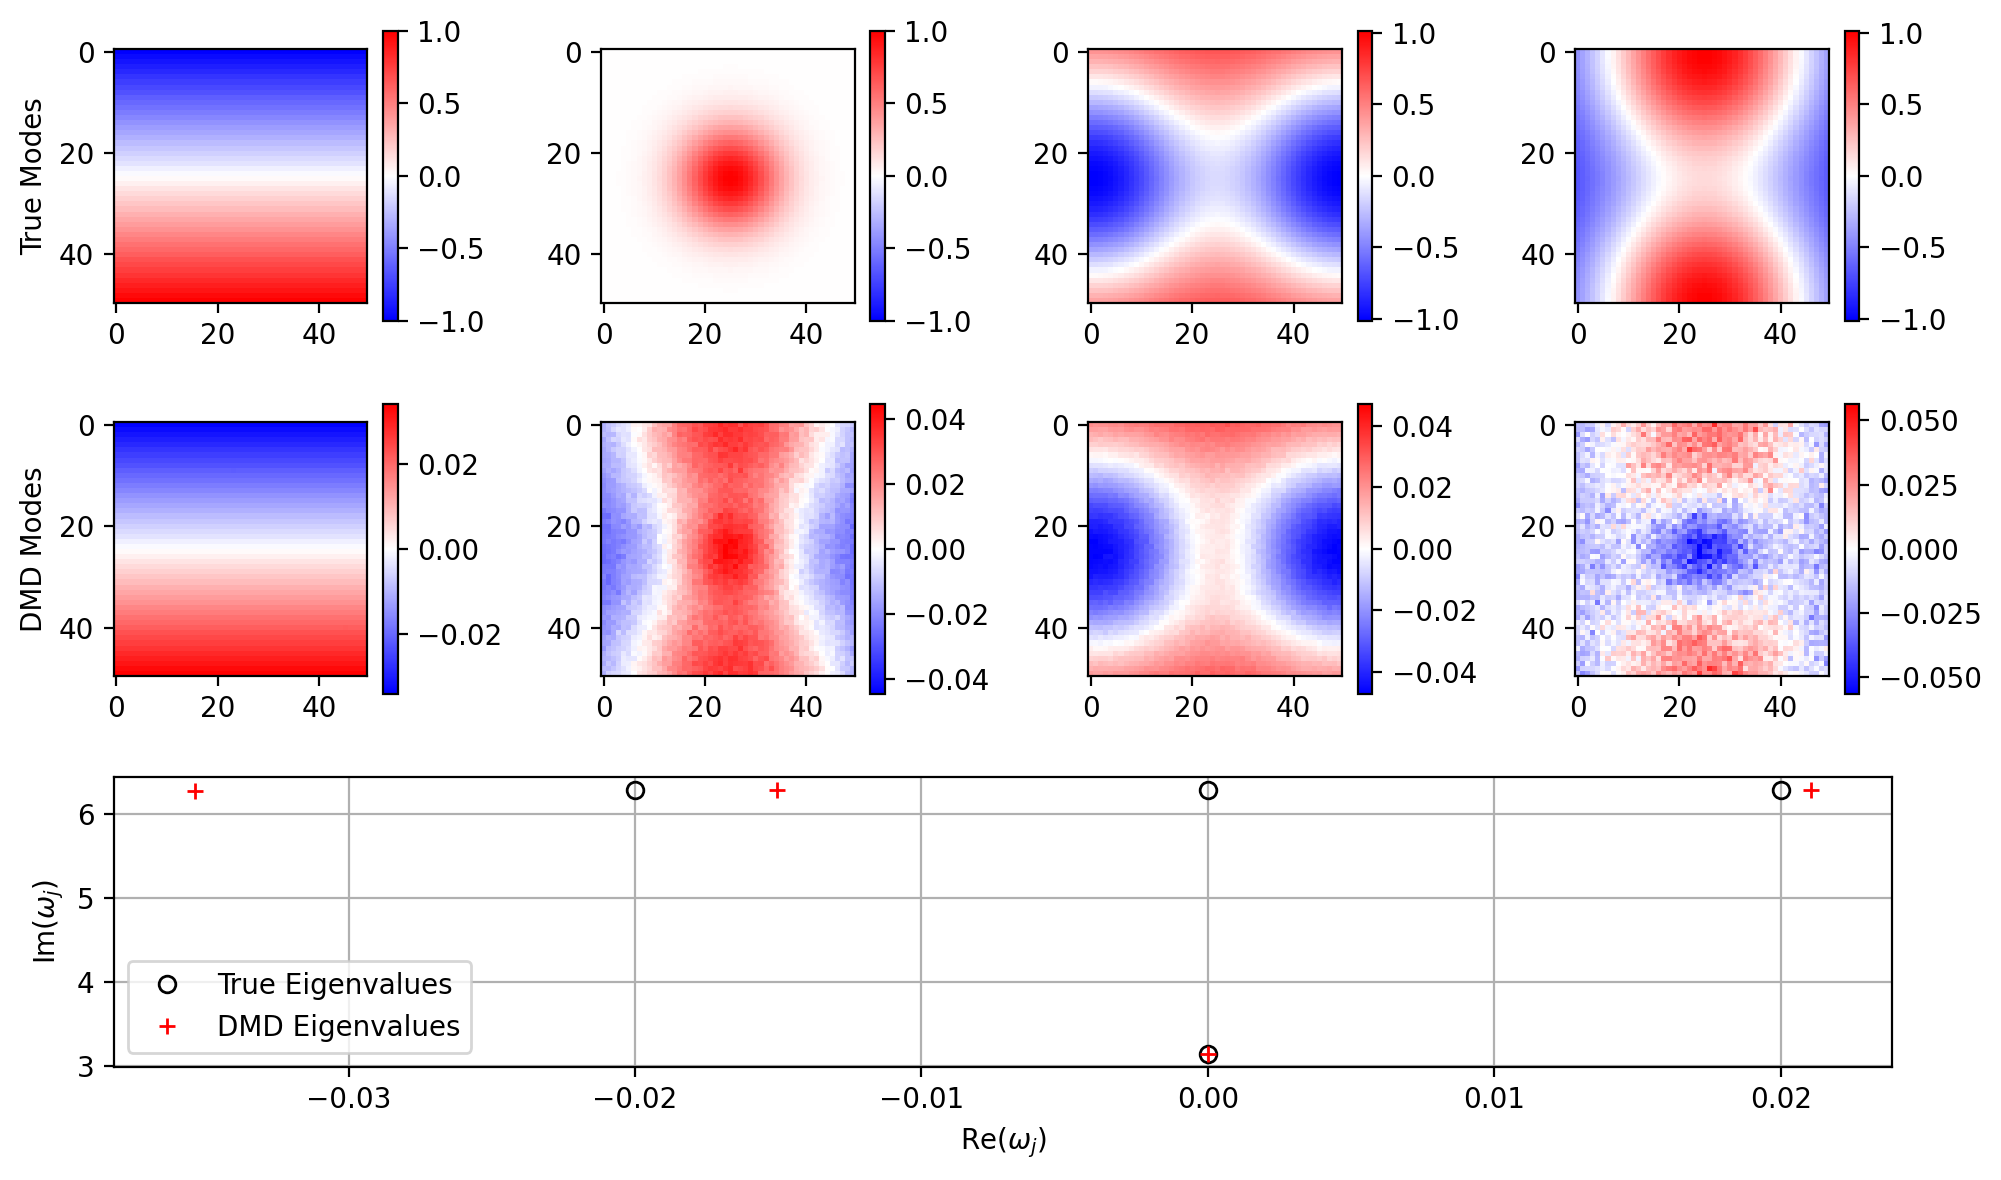

Results for lambda = 2e-05:
Model Error = 0.03783634981786499%


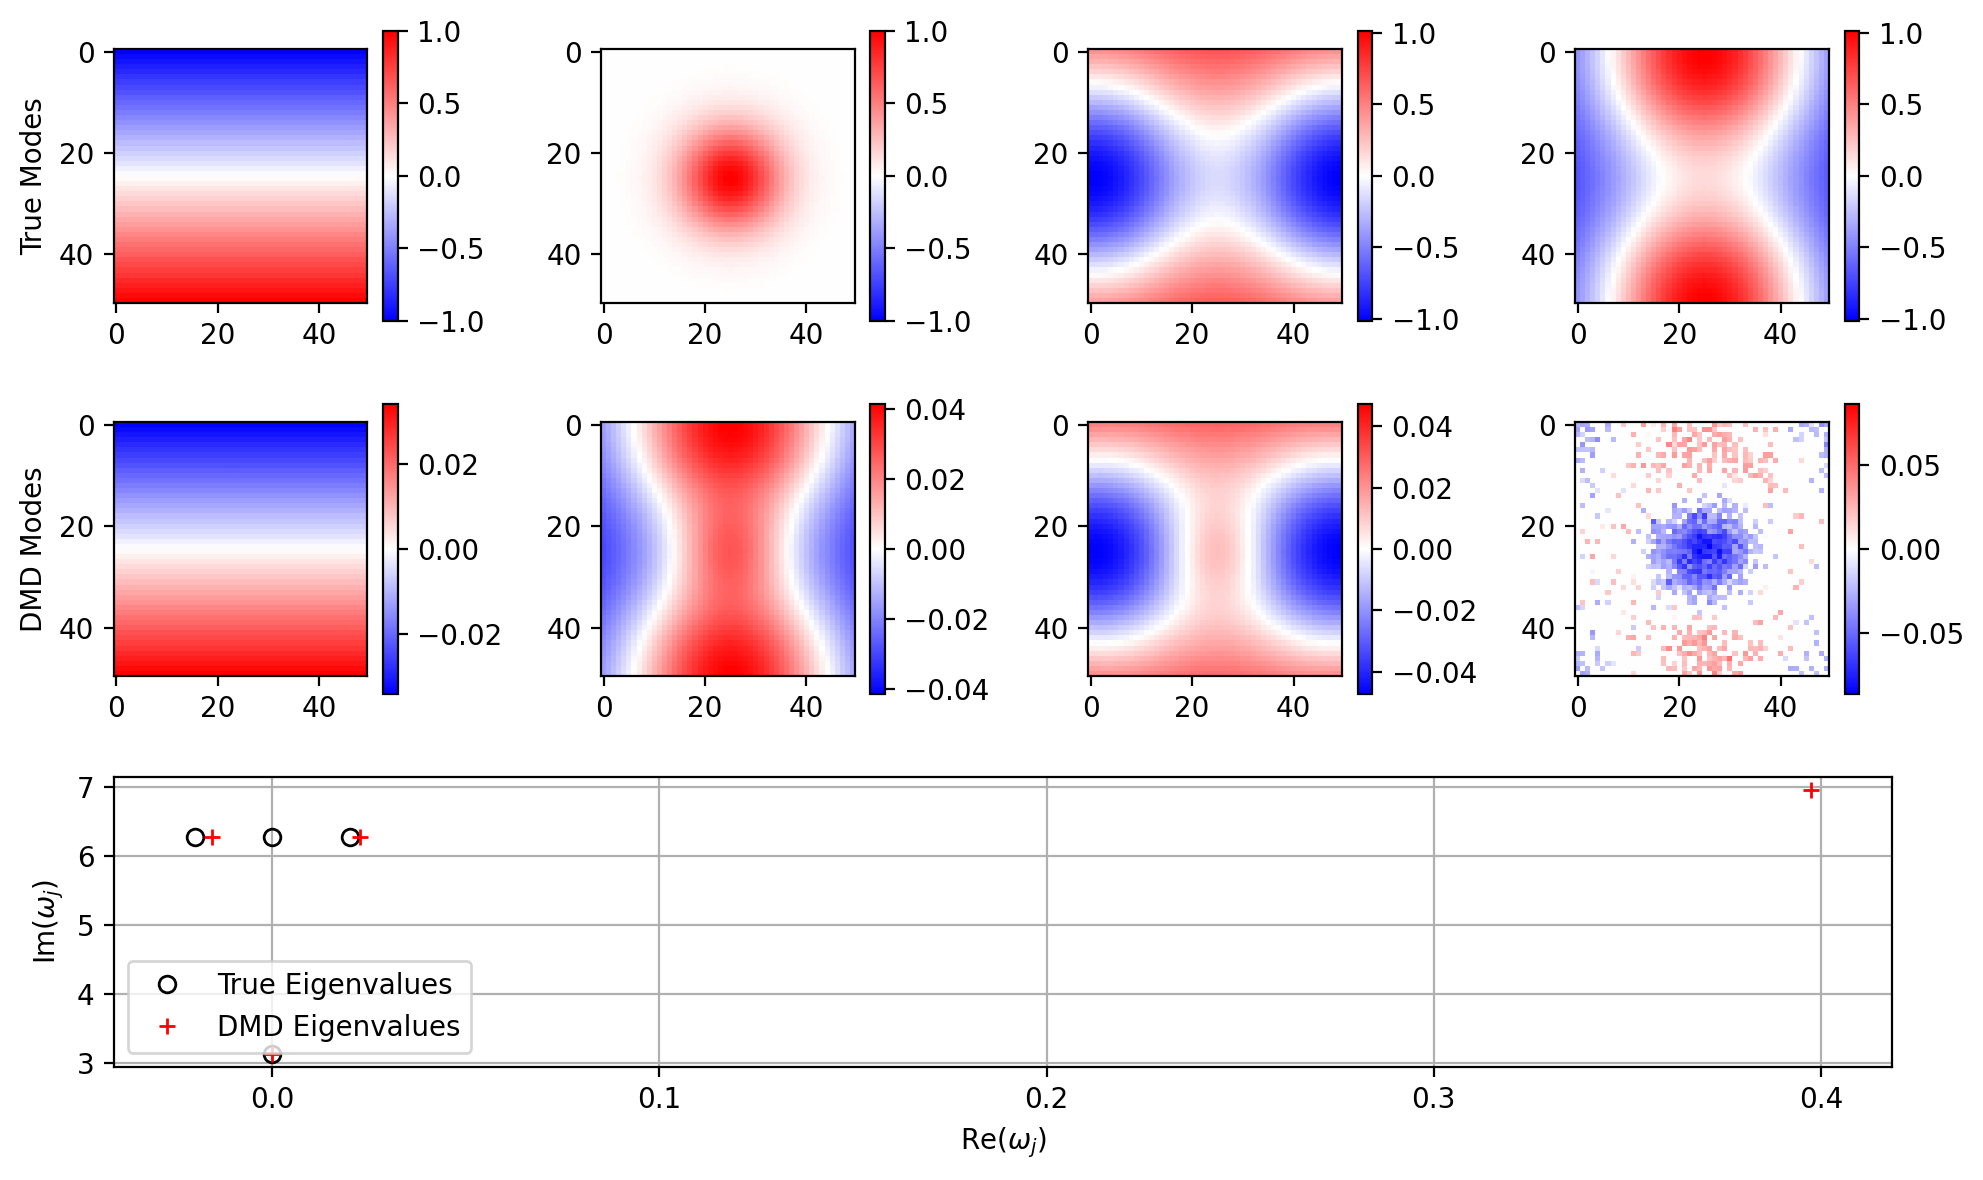

Results for lambda = 4e-05:
Model Error = 0.034170819353106764%


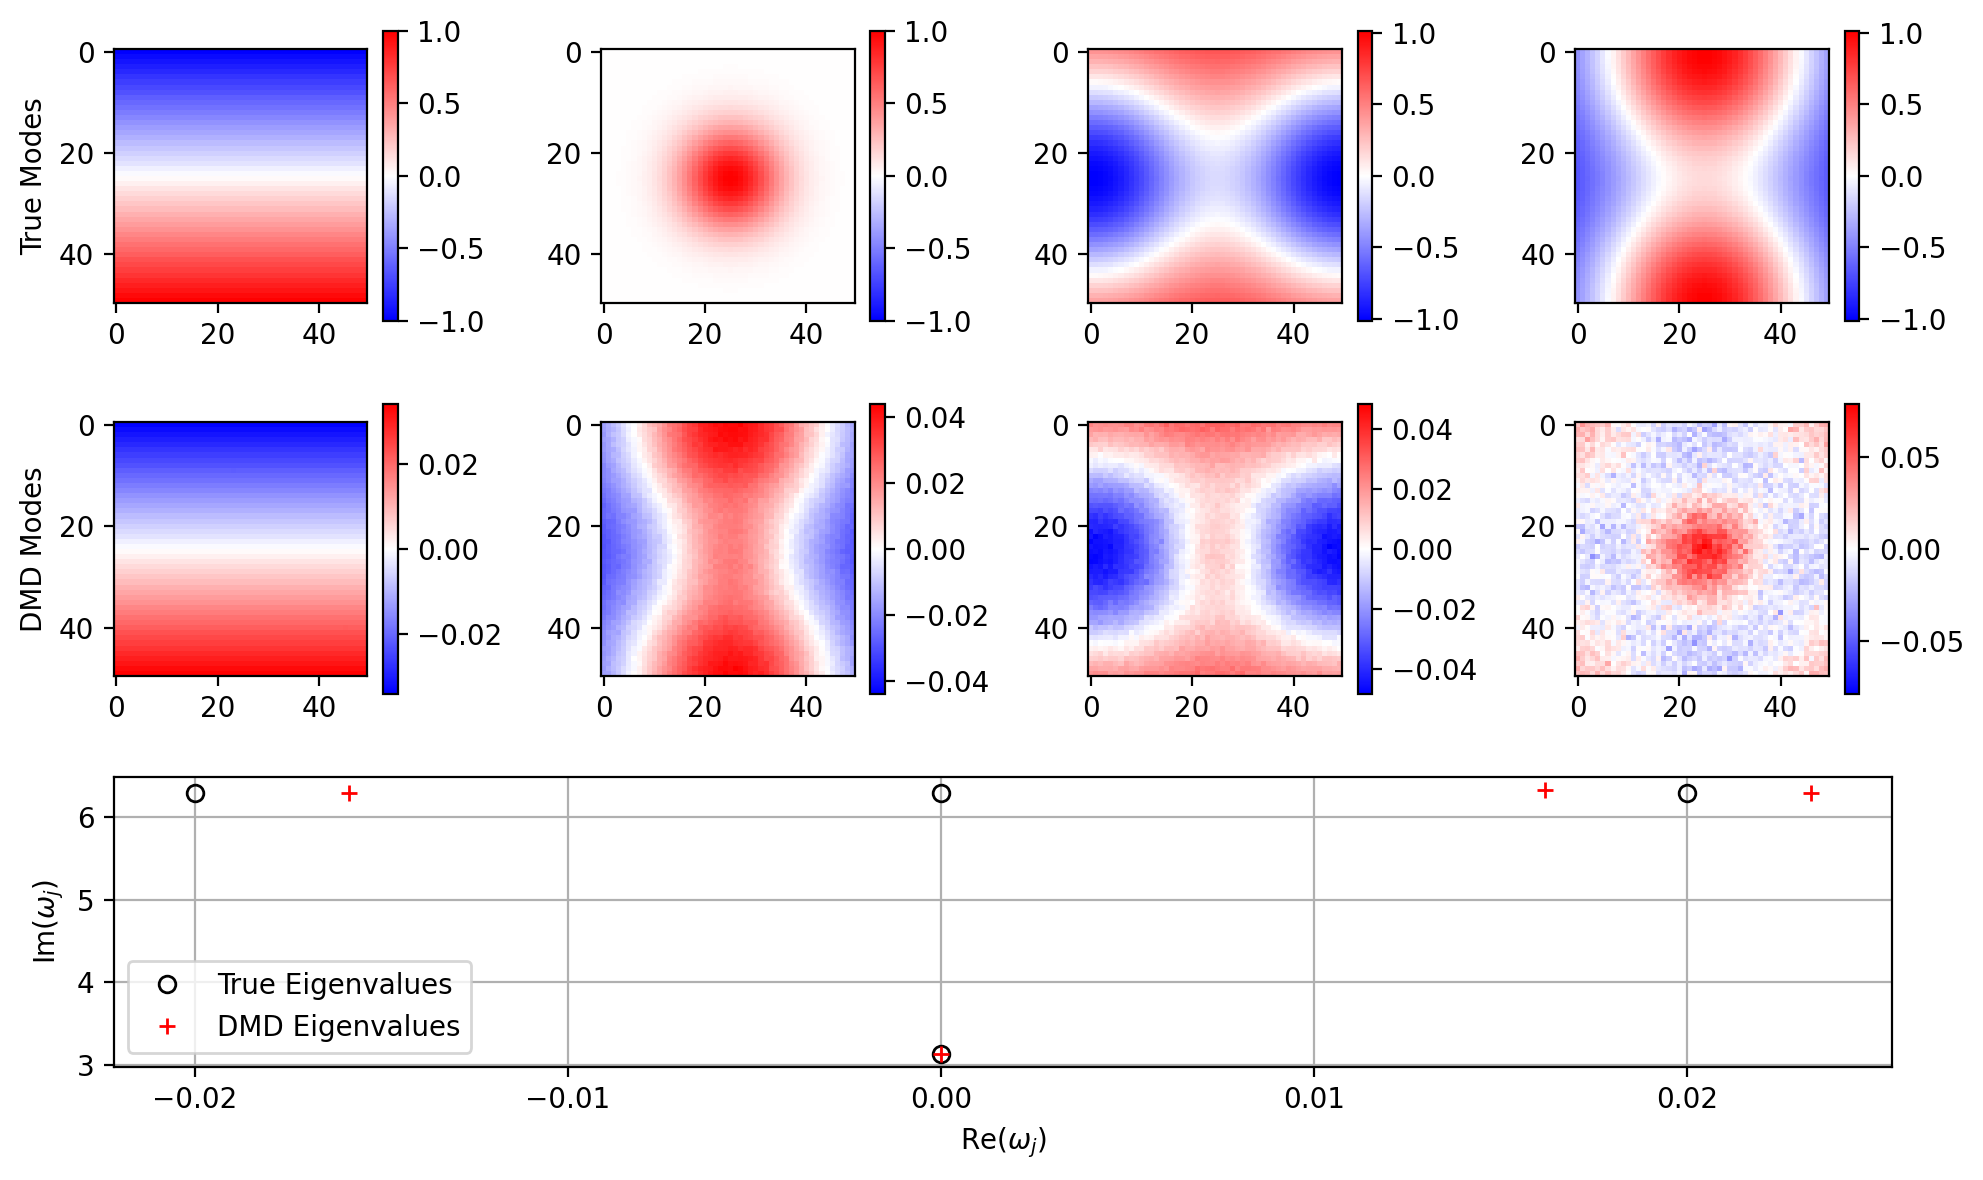

In [8]:
def eig_constraint_func(eigenvalues, real_max=0.1):
    unstable = eigenvalues.real > real_max
    eigenvalues[unstable] = 1j * eigenvalues[unstable].imag + real_max
    return eigenvalues

lambda_vals = [2e-6, 4e-6, 2e-5, 4e-5]
sp_optdmd_models = []

for i, _lambda in enumerate(lambda_vals):
    print(f"Results for lambda = {_lambda}:")

    if i == 3:
        eig_constraints = eig_constraint_func
    else:
        eig_constraints = None

    # Apply sparse-mode DMD (default model style)
    sp_optdmd_models.append(
        SparseBOPDMD(
            svd_rank=4,
            SR3_step=1,
            mode_regularizer="l1",
            regularizer_params={"lambda": _lambda},
            apply_debias=True,
            eig_constraints=eig_constraints,
            # index_global="auto",
        ).fit(X, t)
    )

    print(f"Model Error = {100 * error(sp_optdmd_models[i].reconstructed_data, X_clean)}%")
    plot_dmd_results(sp_optdmd_models[i].modes.real.T, sp_optdmd_models[i].eigs)

In [9]:
print(f"lambda values: {lambda_vals}")

lambda values: [2e-06, 4e-06, 2e-05, 4e-05]


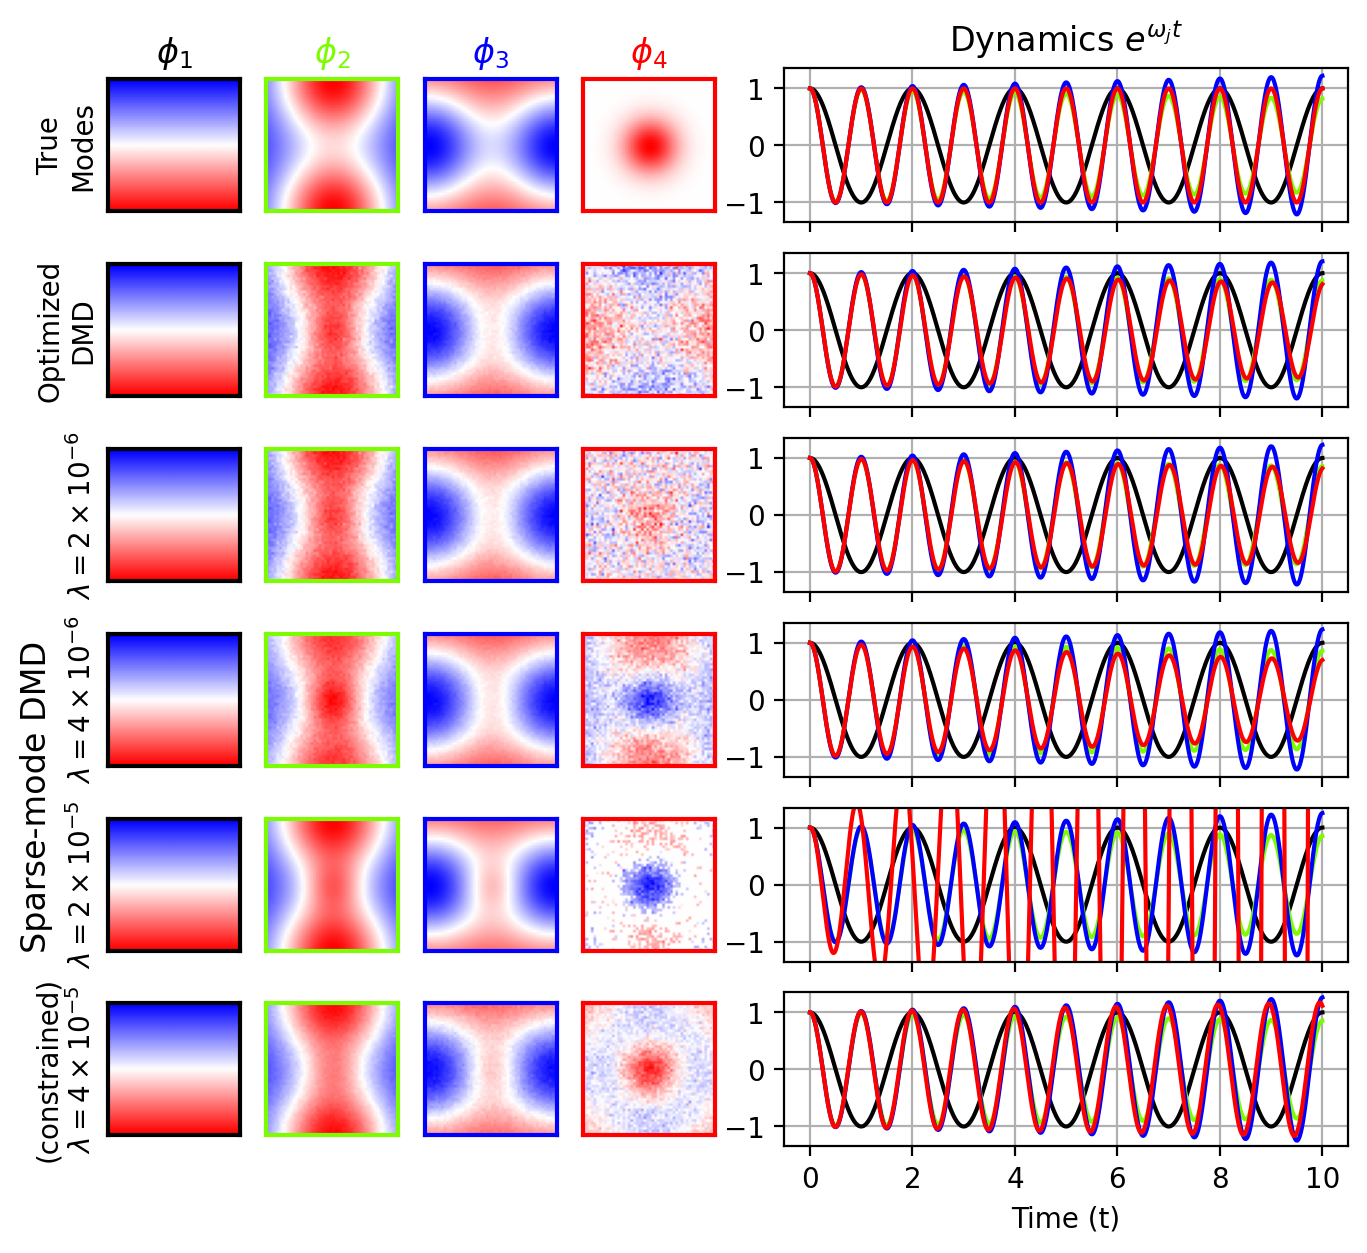

In [10]:
row_titles = [
    "True\nModes",
    "Optimized\nDMD",
    "$\\lambda = 2 \\times 10^{-6}$",
    "$\\lambda = 4 \\times 10^{-6}$",
    "$\\lambda = 2 \\times 10^{-5}$",
    "(constrained)\n$\\lambda = 4 \\times 10^{-5}$",
]
true_mode_rearrange = np.array([0, 3, 2, 1])
all_modes = [
    true_modes[true_mode_rearrange],
    optdmd.modes.real.T,
    sp_optdmd_models[0].modes.real.T,
    sp_optdmd_models[1].modes.real.T,
    sp_optdmd_models[2].modes.real.T,
    sp_optdmd_models[3].modes.real.T,
]
all_eigs = [
    true_eigs[true_mode_rearrange],
    optdmd.eigs,
    sp_optdmd_models[0].eigs,
    sp_optdmd_models[1].eigs,
    sp_optdmd_models[2].eigs,
    sp_optdmd_models[3].eigs,
]
mode_colors = ["k", "lawngreen", "b", "r"]

fig = plt.figure(figsize=(8, 7), dpi=200)

for k, title in enumerate(row_titles):
    # Plot the modes.
    for i, mode in enumerate(all_modes[k]):
        ax = fig.add_subplot(6, 8, 8 * k + i + 1)
        vmax = np.abs(mode).max()
        im = ax.imshow(mode.reshape(ny, nx), cmap="bwr", vmin=-vmax, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        # fig.colorbar(im, ax=ax)
        if k == 0:
            ax.set_title(f"$\\phi_{i + 1}$", c=mode_colors[i])
        if i == 0:
            ax.set_ylabel(title)
        for spine in ax.spines.values():
            spine.set_color(mode_colors[i])
            spine.set_linewidth(1.5)

    # Plot the dynamics.
    ax = fig.add_subplot(6, 2, 2 * k + 2)
    ax.set_ylim([-1.35, 1.35])
    ax.grid()
    for i, eig in enumerate(all_eigs[k]):
        ax.plot(t, np.exp(eig * t).real, c=mode_colors[i])
    if k < 5:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time (t)")
    if k == 0:
        ax.set_title("Dynamics $e^{\\omega_j t}$")

fig.supylabel("Sparse-mode DMD", x=0.07, y=0.36)
plt.show()